# Cropping

Implements the third stage of *[Automated Low-Cost Photogrammetric Acquisition of 3D Models from
Small Form-Factor Artefacts](https://www.mdpi.com/2079-9292/8/12/1441)* (Collins et al., 2019),
following on from [dense_reconstruction.ipynb](dense_reconstruction.ipynb).

> Cropping is the removal of unwanted points that do not form part of the object being
> acquired&mdash;mostly points representing the turntable and calibration pattern and any
> supporting material used to stabilise the object during the acquisition. A dark coloured
> supporting foam material was chosen to contrast with the much lighter colour of the cuneiform
> fragments so that it could be automatically identified and removed. The calibration model used
> during bundle adjustment lies on the z = 0 plane, so most of the extraneous points lie outside
> an axis-aligned bounding box with an x and y extent equal to the size of the calibration pattern
> and a z extent from the maximum z-coordinate in the point-cloud down to a few millimetres above
> the turntable surface. The actual lower z-limit used is derived by progressively calculating the
> average luminosity of points in millimetre-by-millimetre slices starting at z = 2 mm above the
> turntable and increasing z until an average luminosity threshold is exceeded.

**Pipeline in this notebook:**
1. Load Step 5's own raw, **unfiltered** StereoFusion output (`outputs/<set>/dense/fused`) - not
   `dense_raw.ply`, which already applied Step 5's own rough *spherical* ROI filter as a stand-in
   for this exact stage (see that notebook's Step 5). Starting from the unfiltered cloud gives the
   x/y box crop below real work to do: a phone-camera capture reconstructs plenty of turntable rim
   and background well outside the calibration pattern.
2. **Correct a known Step 4 orientation bug** (Step 2 below) - this replica's real-camera
   reconstruction comes out mirrored through the z = 0 plane, artefact-below-turntable instead of
   above it.
3. **Level the turntable tilt** (Step 3 below) - not in the paper, added for this replica: the
   calibration model fixes the pattern at world Z&nbsp;=&nbsp;0 by construction, but the *real*,
   physically captured turntable doesn't have to be level in that same frame, and the z-based
   crop below assumes it is. A RANSAC plane fit finds the real pattern/turntable plane and the
   cloud is rotated so that plane sits back at Z&nbsp;=&nbsp;0.
4. **x/y crop** to an axis-aligned square the size of the calibration pattern (130&times;130&nbsp;mm,
   centred at the world origin - the same plane the pattern is defined on during calibration).
5. **Fixed z lower-limit** (Step 5 below) - `Z_START_OFFSET_MM` (2mm) above the turntable, not a
   search. The paper's own method here *is* a luminosity-threshold search for where dark support
   material ends; this replica's own captures never use any dark support material, and measured
   directly against real data, that search actively mis-fired - it mistook the artefact's own
   (genuinely dark-toned) lower/mid body for support material and cropped a large chunk of it
   away. See Step 5's own markdown for the full diagnosis.
6. **z upper-limit via a density gap** (Step 6 below) - not in the paper, added for this replica:
   StereoFusion consistently leaves a small blob of disconnected debris floating well above the
   artefact (almost certainly a specular-highlight fusion ghost). A gap in point density between
   the artefact's own mass and that debris is used to cut it.
7. **Crop** to the resulting box.
8. **Keep the largest connected component** (Step 8 below) - not in the paper, added for this
   replica after Step 6's density-gap cutoff turned out not to be strict enough on its own:
   diagnosed on two real captures where a large, disconnected, distinctly different-coloured mass
   survived cropping in both sets because the real gap separating it from the artefact (~1-3mm)
   was well under Step 6's 5mm requirement. Since one artefact on a turntable should be exactly
   one connected piece of matter once the turntable/pattern is cropped away, this keeps only the
   single largest connected component and drops everything else, no matter how large - see
   `cropping.keep_largest_component`'s own docstring for the full diagnosis. Writes the cropped,
   coloured point cloud to `outputs/<set>/cropped/cropped.ply`, ready for Step 7 (Point Cloud
   Registration).

**Notes on this replica:**
- The images in `images/set_*` were captured with the miniature sitting directly on the
  calibration pattern - no dark foam raiser underneath it, unlike the paper's cuneiform-fragment
  setup - and the printed pattern itself measures about 1mm thick in the real reconstruction. So
  the z-crop here needs no search at all: a fixed `Z_START_OFFSET_MM` (2mm) above the turntable
  already clears the pattern and keeps the whole artefact above it. The paper's own luminosity
  search was tried first, since a real capture's own paint is often darker near its base and
  lighter further up (which the search would have to see through) - but it actively mis-fired on
  this data, mistaking the artefact's own darker-toned body for support material and cropping a
  large chunk of the object away (see Step 5's markdown for the full, real-data diagnosis).
- The floating-debris cutoff (Step 6) is this replica's own addition, not the paper's - it exists
  because this specific capture/reconstruction setup consistently produces one small disconnected
  cluster of junk points per set. It's a simple, generic density-gap heuristic, not a general
  outlier remover, and on its own isn't always strict enough - see Step 8, added after Step 6
  alone let a real floating blob through on two different captures.
- **The turntable tilt correction (Step 3)** is this replica's own addition too, added after a
  real capture (`set_2`) turned out to have a physically tilted rig (~14 degrees) that was
  spreading the pattern's own flat surface across a 46mm z-range and letting the z-crop below cut
  into the artefact on one side while keeping unwanted pattern/turntable material on the other -
  see `cropping.fit_dominant_plane`/`cropping.level_plane`'s own docstrings for the full account.

In [16]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pycolmap

from utils import cropping as cr
from utils import dense_reconstruction as dr

## Parameters

In [17]:
SET_NAME = "set_1"

ROOT = Path.cwd()
FUSED_DIR = ROOT / "outputs" / SET_NAME / "dense" / "fused"  # Step 5's raw, unfiltered fusion output
OUT_DIR = ROOT / "outputs" / SET_NAME / "cropped"
OUT_PLY = OUT_DIR / "cropped.ply"

# Calibration pattern footprint (Step 1/4) - the crop box's x/y extent.
PATTERN_SIZE_MM = 130.0

# z lower-limit: a *fixed* offset above the turntable (paper spec: 2mm) - see Step 5 for why this
# replica uses the fixed offset directly rather than the paper's own luminosity-threshold search.
TURNTABLE_Z_MM = 0.0  # the calibration model's own z=0 plane, fixed during Step 4's bundle adjustment
Z_START_OFFSET_MM = 2.0
Z_SLICE_THICKNESS_MM = 1.0  # slice thickness for the diagnostic luminosity profile (Step 5/6)
LUMINOSITY_THRESHOLD = 100.0  # reference line only in Step 6's diagnostic plot - not used to crop

# Turntable-tilt plane fit (Step 3) - RANSAC 3-point plane hypotheses over the x/y-cropped cloud,
# scored by inlier count within this distance, then refit by SVD through the inlier set.
PLANE_FIT_DISTANCE_THRESHOLD_MM = 1.0
PLANE_FIT_N_TRIALS = 2000

# Largest-connected-component keep (Step 8) - connects points within ISOLATION_RADIUS_MM of each
# other, then keeps only the single largest resulting component (see that step's own markdown for
# the real "floating blob" case this catches). Warn if that drops an unusually high fraction of
# the cropped cloud - worth a second look rather than a silent surprise.
ISOLATION_RADIUS_MM = 1.5
CROP_LARGEST_COMPONENT_FRACTION_WARN = 0.3

# z upper-limit: cut off at the first density gap this thick, once point density drops
# below this many points/slice - see Step 6. Not paper spec; see the notebook intro.
GAP_THICKNESS_MM = 5.0
MIN_POINTS_PER_SLICE = 5

if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir(parents=True)

## Step 1 - Load Step 5's raw dense point cloud

The unfiltered StereoFusion output - every point PatchMatchStereo + StereoFusion produced,
including the turntable, calibration pattern, and any background dense stereo happened to
reconstruct.

In [18]:
fused = pycolmap.Reconstruction()
fused.read(str(FUSED_DIR))
points, colors = dr.points_and_colors(fused)

print(f"raw fused points: {len(points):,}")
print("bounding box min (mm):", points.min(axis=0))
print("bounding box max (mm):", points.max(axis=0))

radii = np.linalg.norm(points[:, :2], axis=1)
print(f"points beyond the pattern's half-diagonal ({PATTERN_SIZE_MM/2:.0f}mm radius from origin): "
      f"{(radii > PATTERN_SIZE_MM/2).sum():,} / {len(points):,}")

raw fused points: 2,734,891
bounding box min (mm): [-205.57870483 -118.52677917  -70.87195587]
bounding box max (mm): [162.77612305 201.89707947  50.39601135]
points beyond the pattern's half-diagonal (65mm radius from origin): 1,582,153 / 2,734,891


## Step 2 - Correct a known Step 4 orientation bug

The real-camera reconstruction from Step 4 comes out **mirrored through the z&nbsp;=&nbsp;0
plane**: instead of the artefact sitting above the turntable (positive z, towards the camera),
it reconstructs *below* it. This is Step 4's own coplanar-target pose ambiguity (see
`plate_geometry.look_at_origin`'s docstring - "two camera centres related by reflection through
the Z=0 plane... produce the two poses a coplanar point set cannot distinguish by reprojection
error alone") resolving to the wrong sign for this capture rig. It isn't specific to this
notebook either - the same downward-hanging cluster is already visible, unflipped, in Step 5's own
diagnostic plot.

`cropping.correct_z_axis_inversion` negates z to restore the convention the rest of this notebook
(and the paper) assumes. This is a workaround at the data-consumption end - the proper fix belongs
in `colmap_calibration.py`'s pose disambiguation - but it lets this step produce a correct crop
today without re-running Steps 4-5.

In [19]:
raw_points = points.copy()
points = cr.correct_z_axis_inversion(points)
print("z range before correction:", f"{raw_points[:, 2].min():.1f} .. {raw_points[:, 2].max():.1f}")
print("z range after correction: ", f"{points[:, 2].min():.1f} .. {points[:, 2].max():.1f}")

z range before correction: -70.9 .. 50.4
z range after correction:  -50.4 .. 70.9


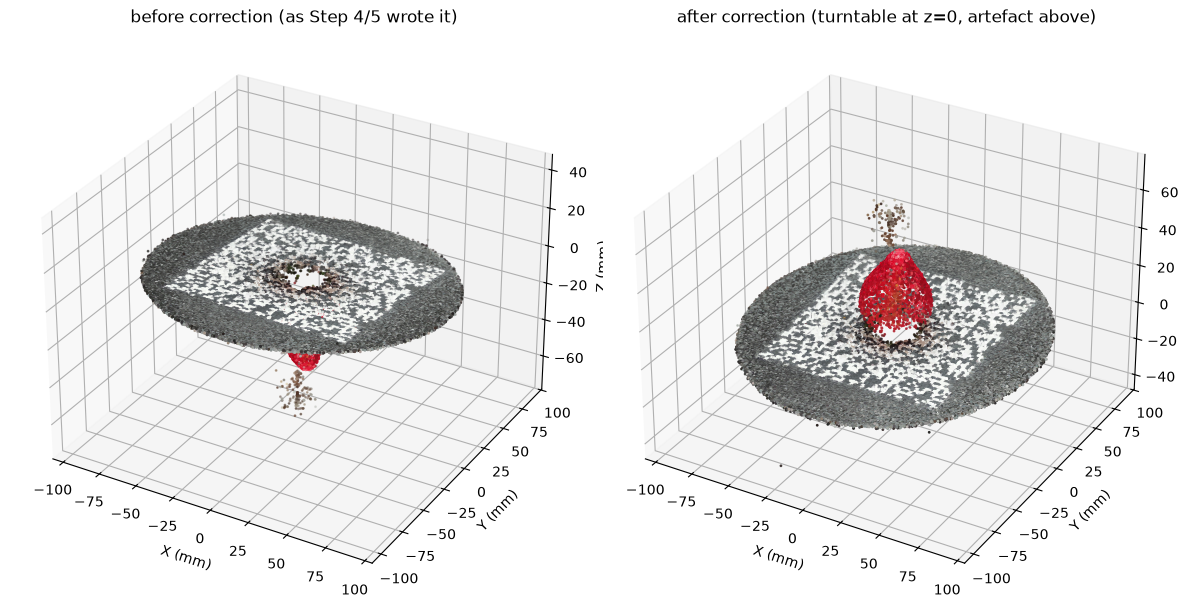

In [20]:
fig = plt.figure(figsize=(12, 6))
for i, (p, title) in enumerate([(raw_points, "before correction (as Step 4/5 wrote it)"),
                                  (points, "after correction (turntable at z=0, artefact above)")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    sample = np.random.default_rng(0).choice(len(p), size=min(60_000, len(p)), replace=False)
    ax.scatter(p[sample, 0], p[sample, 1], p[sample, 2], c=colors[sample] / 255.0, s=1)
    ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)"); ax.set_zlabel("Z (mm)")
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Step 3 - Level the turntable tilt

Not in the paper - added after finding a real capture (`set_2`) whose physical rig sat at a
slight angle, so the pattern/turntable itself came out tilted relative to the calibration
model's own (perfectly flat, by construction) world Z&nbsp;=&nbsp;0 plane. The z-based crop
below assumes a level, constant-Z turntable; a tilted one lets one side of the artefact get cut
away (the tilted surface rises above the z-search's assumed height sooner) while the other side
keeps unwanted turntable/pattern material (the surface hasn't yet fallen below it).
`cropping.fit_dominant_plane` finds the real pattern/turntable plane via RANSAC (robust to the
artefact itself being a minority of non-planar points sitting on that plane), and
`cropping.level_plane` rotates the cloud so that plane sits back at z&nbsp;=&nbsp;0 - see both
functions' own docstrings for the full diagnosis and the real numbers from `set_2` (a ~14&deg;
tilt that spread the pattern's own points across a 46mm z-range before correction, and under
2.4mm after).

In [21]:
xy_points_for_plane, _, _ = cr.crop_xy(points, colors, PATTERN_SIZE_MM)
plane = cr.fit_dominant_plane(
    xy_points_for_plane,
    distance_threshold_mm=PLANE_FIT_DISTANCE_THRESHOLD_MM,
    n_trials=PLANE_FIT_N_TRIALS,
)
print(f"fitted turntable plane: {plane.tilt_deg:.1f} deg from level, "
      f"{plane.inlier_fraction:.1%} of the x/y-cropped cloud lies on this one plane")

points_before_leveling = points.copy()
points = cr.level_plane(points, plane)

fitted turntable plane: 4.4 deg from level, 89.9% of the x/y-cropped cloud lies on this one plane


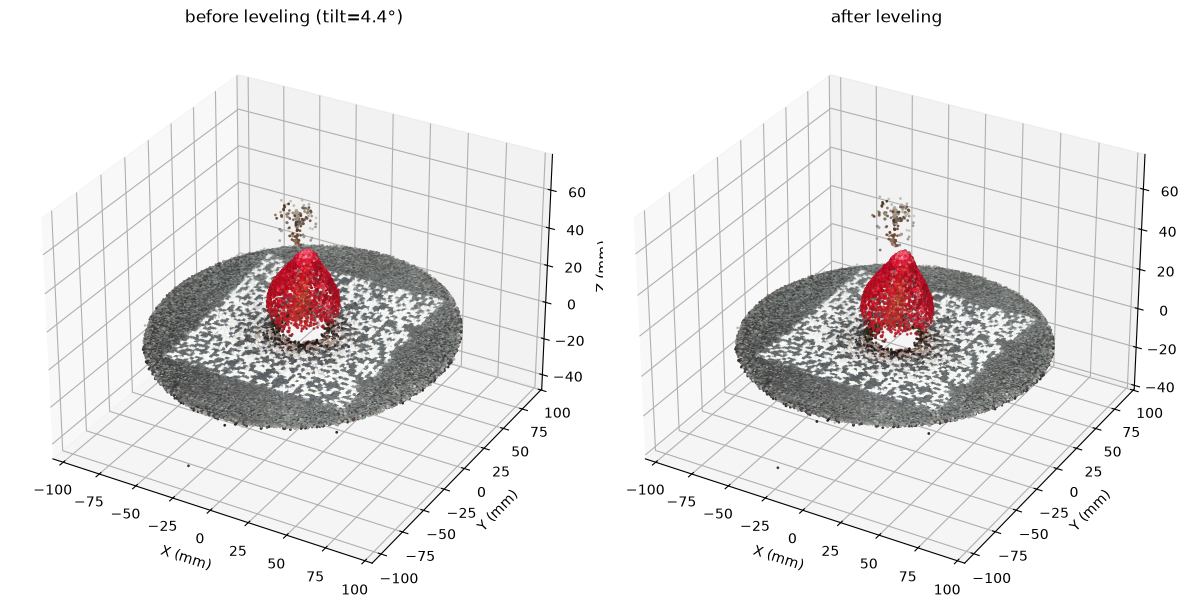

In [22]:
fig = plt.figure(figsize=(12, 6))
for i, (p, title) in enumerate([
    (points_before_leveling, f"before leveling (tilt={plane.tilt_deg:.1f}\u00b0)"),
    (points, "after leveling"),
]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    sample = np.random.default_rng(0).choice(len(p), size=min(60_000, len(p)), replace=False)
    ax.scatter(p[sample, 0], p[sample, 1], p[sample, 2], c=colors[sample] / 255.0, s=1)
    ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)"); ax.set_zlabel("Z (mm)")
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Step 4 - x/y crop to the calibration pattern's footprint

Keeps only points whose (x, y) falls inside the pattern's own 130&times;130&nbsp;mm square,
centred at the world origin. This alone discards most of the turntable rim and background
clutter picked up by dense stereo matching outside the pattern.

In [23]:
xy_points, xy_colors, xy_mask = cr.crop_xy(points, colors, PATTERN_SIZE_MM)
print(f"x/y crop: {len(xy_points):,} / {len(points):,} points kept "
      f"({len(xy_points)/len(points):.1%})")
print("kept bounding box min/max (mm):", xy_points.min(axis=0), xy_points.max(axis=0))

x/y crop: 1,588,492 / 2,734,891 points kept (58.1%)
kept bounding box min/max (mm): [-64.99989791 -64.99998161 -47.00385371] [64.9999941  64.9999561  69.79444862]


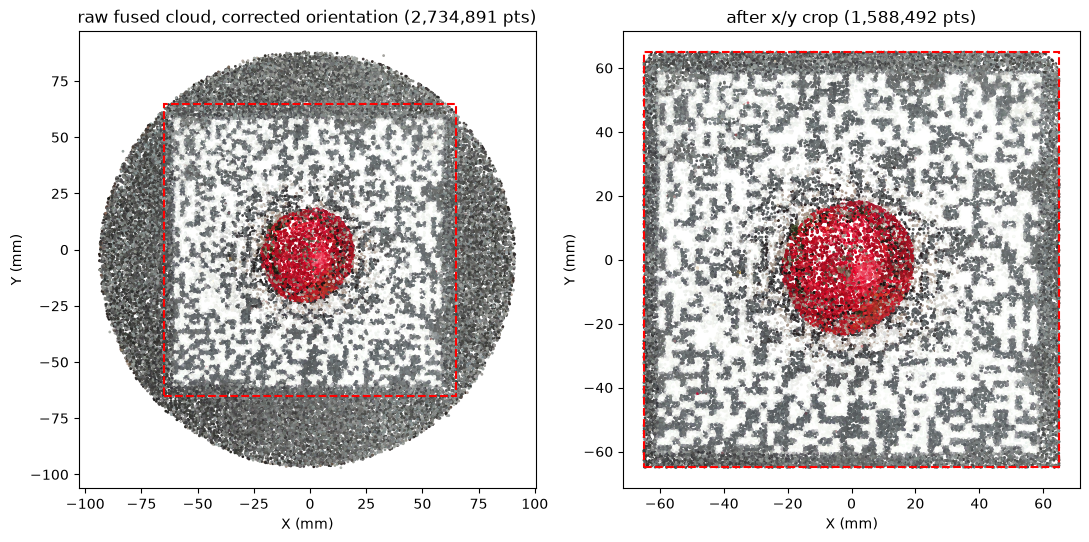

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, (p, c, title) in zip(axes, [
    (points, colors, f"raw fused cloud, corrected orientation ({len(points):,} pts)"),
    (xy_points, xy_colors, f"after x/y crop ({len(xy_points):,} pts)"),
]):
    sample = np.random.default_rng(0).choice(len(p), size=min(60_000, len(p)), replace=False)
    ax.scatter(p[sample, 0], p[sample, 1], c=c[sample] / 255.0, s=1)
    half = PATTERN_SIZE_MM / 2.0
    ax.add_patch(plt.Rectangle((-half, -half), PATTERN_SIZE_MM, PATTERN_SIZE_MM,
                                fill=False, edgecolor="red", linewidth=1.5, linestyle="--"))
    ax.set_title(title)
    ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Step 5 - Fixed z lower-limit + luminosity profile (diagnostic only)

`Z_LIMIT` is a **fixed** offset (`Z_START_OFFSET_MM` above the turntable), not a search. The
paper's own method here is a search: slide a 1mm slab upward, averaging luminosity, until it
crosses a threshold - the point where dark supporting material gives way to the artefact. That's
the right method for a setup that hides the object on dark foam. This replica's own captures
don't use any, though: measured directly against real data, the printed pattern is one dominant,
bright, neutral-grey point mass right at z&nbsp;=&nbsp;0, and the artefact's own material begins
immediately above it (a 100x+ point-count drop between z=0 and z=1mm) - there's no separate dark
material to search for. Worse, the search actively mis-fired on this data: the artefact's own
lower/mid body reads dark under Rec.601 luminosity for tens of millimetres before brightening
near its top, so the search mistook real artefact material for support material and cropped away
a large chunk of the object - see `cropping.find_lower_z_limit`'s own docstring for the full
diagnosis. That function is still correct for a setup that genuinely needs it; this notebook just
doesn't call it any more.

The luminosity profile below is still computed and plotted (Step 6's diagnostic chart) - useful
to *look at* and confirm there's no real dark-material transition to find, but no longer used to
make the crop decision.

In [25]:
z_limit = TURNTABLE_Z_MM + Z_START_OFFSET_MM
z_max = float(xy_points[:, 2].max()) if len(xy_points) else z_limit
profile = cr.compute_luminosity_profile(
    xy_points, xy_colors, slice_thickness_mm=Z_SLICE_THICKNESS_MM, z_min=z_limit, z_max=z_max,
)
print(f"z lower limit: {z_limit:.1f}mm (fixed offset, not searched)")
print(f"{len(profile)} slice(s) examined between {z_limit:.1f}mm and the cloud's max z ({z_max:.1f}mm), for the diagnostic plot below")

z lower limit: 2.0mm (fixed offset, not searched)
68 slice(s) examined between 2.0mm and the cloud's max z (69.8mm), for the diagnostic plot below


## Step 6 - z upper-limit: trim disconnected debris

Not part of the paper's method. This replica's dense reconstruction consistently leaves one
small, disconnected clump of points floating well above the artefact - visible as a gap in the
"points per slice" chart below between the artefact's own tapering mass and that clump. Cutting
at the first `GAP_THICKNESS_MM`-thick run of near-empty slices keeps the artefact (including any
genuinely thin extremities that taper off gradually) while dropping the disconnected debris.

In [26]:
z_upper_limit = cr.find_upper_z_limit(
    profile, fallback_z_max=z_max,
    gap_thickness_mm=GAP_THICKNESS_MM, min_points_per_slice=MIN_POINTS_PER_SLICE,
)
if z_upper_limit < z_max:
    print(f"density gap found: cutting at z={z_upper_limit:.1f}mm (cloud's own max was {z_max:.1f}mm)")
else:
    print(f"no density gap found up to {z_max:.1f}mm - nothing above the artefact to cut "
          f"(Step 8's largest-component keep is still the backstop for the floating-blob case)")

no density gap found up to 69.8mm - nothing above the artefact to cut (Step 8's largest-component keep is still the backstop for the floating-blob case)


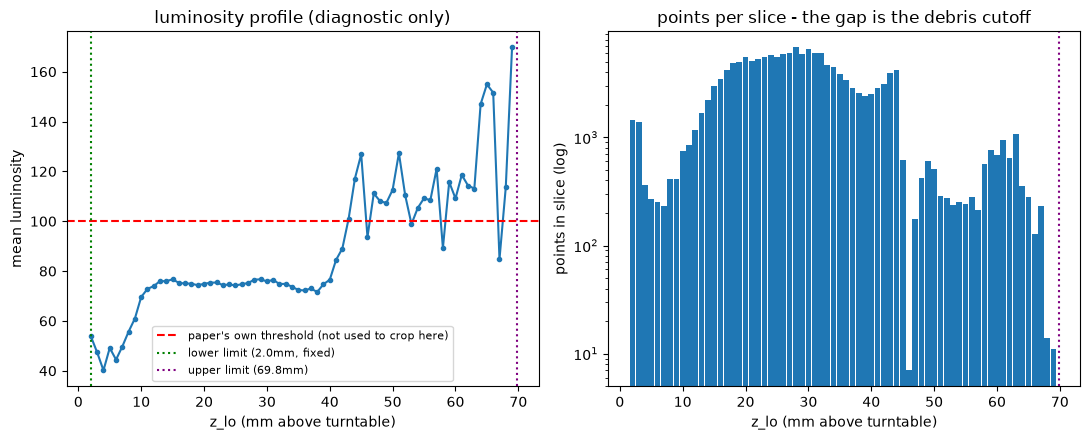

In [27]:
z_los = [s.z_lo for s in profile]
mean_lums = [s.mean_luminosity for s in profile]
counts = [s.num_points for s in profile]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True)
axes[0].plot(z_los, mean_lums, marker="o", markersize=3)
axes[0].axhline(LUMINOSITY_THRESHOLD, color="red", linestyle="--", label="paper's own threshold (not used to crop here)")
axes[0].axvline(z_limit, color="green", linestyle=":", label=f"lower limit ({z_limit:.1f}mm, fixed)")
axes[0].axvline(z_upper_limit, color="purple", linestyle=":", label=f"upper limit ({z_upper_limit:.1f}mm)")
axes[0].set_xlabel("z_lo (mm above turntable)"); axes[0].set_ylabel("mean luminosity")
axes[0].set_title("luminosity profile (diagnostic only)"); axes[0].legend(fontsize=8)

axes[1].bar(z_los, counts, width=Z_SLICE_THICKNESS_MM * 0.9)
axes[1].axvline(z_upper_limit, color="purple", linestyle=":")
axes[1].set_yscale("log")
axes[1].set_xlabel("z_lo (mm above turntable)"); axes[1].set_ylabel("points in slice (log)")
axes[1].set_title("points per slice - the gap is the debris cutoff")
plt.tight_layout()
plt.show()

## Step 7 - Apply the crop

x/y box + z from the derived lower limit up to the derived upper limit.

In [28]:
cropped_points, cropped_colors, crop_mask = cr.crop_to_pattern_and_z(
    points, colors, PATTERN_SIZE_MM, z_limit, z_upper_limit
)
print(f"cropped: {len(cropped_points):,} / {len(points):,} points kept "
      f"({len(cropped_points)/len(points):.2%})")
if len(cropped_points):
    print("cropped bounding box min/max (mm):", cropped_points.min(axis=0), cropped_points.max(axis=0))

cropped: 158,780 / 2,734,891 points kept (5.81%)
cropped bounding box min/max (mm): [-58.82287893 -25.87595545   2.00194043] [64.54406242 64.81130895 69.79444862]


## Step 8 - Keep the largest connected component

Not part of the crop box/z-limits above. `find_upper_z_limit` (Step 6) assumes disconnected
reconstruction debris sits above the artefact separated by a real *density* gap of
`GAP_THICKNESS_MM` worth of near-empty z-slabs - but diagnosed on two real captures (`set_1` and
`set_2`) where that assumption failed: the cropped cloud split into two large, similarly-sized
connected components with only a ~1-3mm gap between them in z, well under the 5mm the gap search
requires, so it never fired and a second, disconnected mass survived cropping in both sets. Their
own mean colours confirm they're physically different things: the artefact reads strongly warm
in both captures, while the mass sitting just above it reads flat grey-brown in both - consistent
across two unrelated scans, not per-capture noise.

A single small artefact sitting on a turntable, once the turntable/pattern/dark-support material
is already cropped away, should be exactly one connected piece of matter - so unlike a plain
isolated-point filter (which only drops components below some small size threshold, on the
assumption a handful of stray points is debris but any larger group might be real),
`cropping.keep_largest_component` keeps *only* the single largest component and drops every other
one outright, including large ones. See its own docstring for the full diagnosis and real numbers.

In [29]:
before_largest = len(cropped_points)
cropped_points, cropped_colors = cr.keep_largest_component(
    cropped_points, cropped_colors, radius=ISOLATION_RADIUS_MM
)
removed_fraction = (before_largest - len(cropped_points)) / max(before_largest, 1)
print(f"kept largest connected component: {before_largest:,} -> {len(cropped_points):,} points "
      f"({removed_fraction:.1%} dropped as disconnected)")
if removed_fraction > CROP_LARGEST_COMPONENT_FRACTION_WARN:
    print(f"WARNING: an unusually high fraction of points ({removed_fraction:.1%}) were dropped - "
          f"double-check the surviving cloud is really the artefact and not a fragment of it")

cr.write_ply(OUT_PLY, cropped_points, cropped_colors)
print(f"wrote {OUT_PLY}")

kept largest connected component: 158,780 -> 147,596 points (7.0% dropped as disconnected)
wrote /home/gnoceras/ScanningTable/outputs/set_1/cropped/cropped.ply


## Before / after 3D scatter

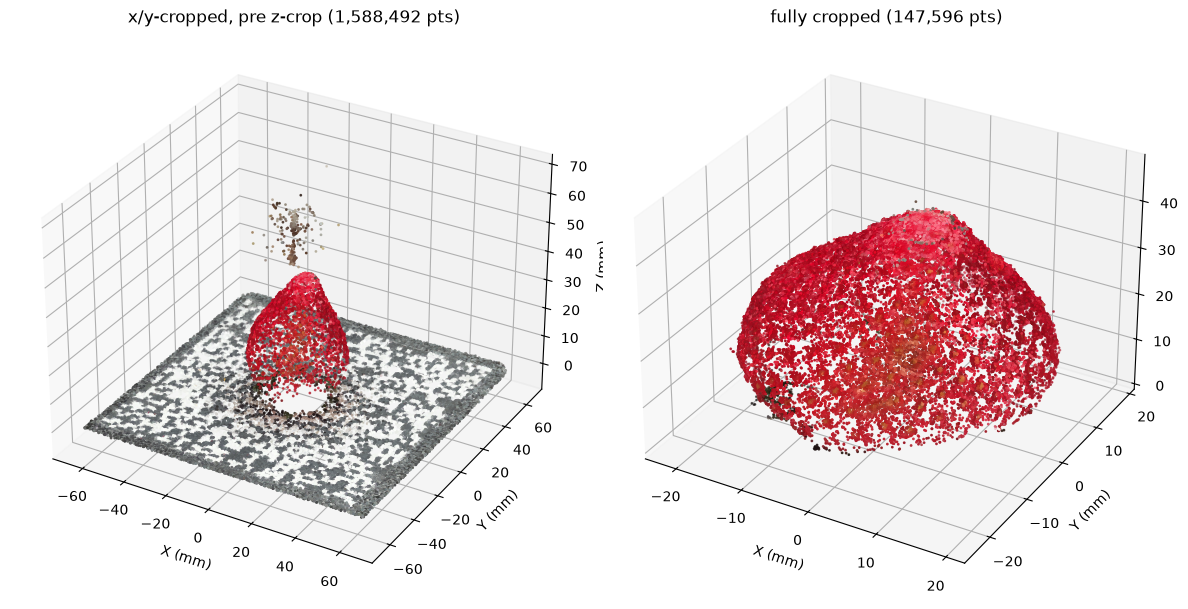

In [30]:
fig = plt.figure(figsize=(12, 6))
for i, (p, c, title) in enumerate([
    (xy_points, xy_colors, f"x/y-cropped, pre z-crop ({len(xy_points):,} pts)"),
    (cropped_points, cropped_colors, f"fully cropped ({len(cropped_points):,} pts)"),
]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    if len(p):
        sample = np.random.default_rng(0).choice(len(p), size=min(40_000, len(p)), replace=False)
        ax.scatter(p[sample, 0], p[sample, 1], p[sample, 2], c=c[sample] / 255.0, s=1)
    ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)"); ax.set_zlabel("Z (mm)")
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Summary

In [31]:
print(f"{SET_NAME}")
print(f"  raw fused points:        {len(points):,}")
print(f"  after x/y crop:          {len(xy_points):,}")
print(f"  z lower limit:           {z_limit:.1f}mm (fixed offset)")
print(f"  z upper limit:           {z_upper_limit:.1f}mm (cloud max was {z_max:.1f}mm)")
print(f"  after full crop:         {before_largest:,}")
print(f"  after largest-component keep: {len(cropped_points):,} ({before_largest - len(cropped_points):,} removed)")
print(f"  wrote:                   {OUT_PLY}")

set_1
  raw fused points:        2,734,891
  after x/y crop:          1,588,492
  z lower limit:           2.0mm (fixed offset)
  z upper limit:           69.8mm (cloud max was 69.8mm)
  after full crop:         158,780
  after largest-component keep: 147,596 (11,184 removed)
  wrote:                   /home/gnoceras/ScanningTable/outputs/set_1/cropped/cropped.ply
